### A MNIST-like fashion product database

In this, we classify the images into respective classes given in the dataset. We use a Neural Net and a Deep Neural Net in Keras to solve this and check the accuracy scores.

### Load tensorflow

In [1]:
import tensorflow as tf
tf.random.set_seed(42)

In [2]:
tf.__version__

'2.0.0-beta1'

### Collect Data

In [3]:
import keras

Using TensorFlow backend.


In [4]:
(trainX, trainY), (testX, testY) = keras.datasets.fashion_mnist.load_data()

In [5]:
print(testY[0:5])

[9 2 1 1 6]


### Convert both training and testing labels into one-hot vectors.

**Hint:** check **tf.keras.utils.to_categorical()**

In [6]:
import numpy as np

In [7]:
np.unique(trainY)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [8]:
testY = tf.keras.utils.to_categorical(testY, num_classes=len(np.unique(testY)))
trainY = tf.keras.utils.to_categorical(trainY, num_classes=len(np.unique(trainY)))

In [9]:
np.unique(trainY)

array([0., 1.], dtype=float32)

In [10]:
print(trainY.shape)
print('First 5 examples now are: ', trainY[0:5])

(60000, 10)
First 5 examples now are:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [11]:
print(trainY.shape)
print('First 5 examples now are: ', trainY[0:5])

(60000, 10)
First 5 examples now are:  [[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### Visualize the data

Plot first 10 images in the triaining set and their labels.

In [12]:
trainX.shape

(60000, 28, 28)

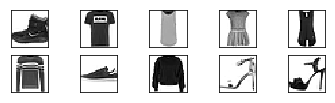

label for each of the above image: [9, 0, 0, 3, 0, 2, 7, 2, 5, 5]


In [13]:
import matplotlib.pyplot as plt
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 
labels = []
#plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(trainX[i], cmap=plt.cm.binary)
    labels.append(np.where(trainY[i] == 1)[0][0])
plt.show()
print("label for each of the above image:", labels)

### Build a neural Network with a cross entropy loss function and sgd optimizer in Keras. The output layer with 10 neurons as we have 10 classes.

In [14]:
#Initialize Sequential model
model = tf.keras.models.Sequential()

#Reshape data from 2D to 1D -> 28x28 to 784
model.add(tf.keras.layers.Reshape((784,),input_shape=(28,28,)))

#Add Dense Layer which provides 10 Outputs after applying softmax
model.add(tf.keras.layers.Dense(10, activation='softmax'))

#Comile the model
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

### Execute the model using model.fit()

In [15]:
model.fit(trainX, trainY, 
          validation_data=(testX, testY), 
          epochs=5,
          batch_size=32)

W0726 15:17:18.599006 140480541943616 deprecation.py:323] From /home/siju/.local/lib/python3.6/site-packages/tensorflow/python/ops/math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 3s 47us/sample - loss: 14.5061 - accuracy: 0.1000 - val_loss: 14.5063 - val_accuracy: 0.1000
Epoch 2/5
60000/60000 [==============================] - 3s 43us/sample - loss: 14.5063 - accuracy: 0.1000 - val_loss: 14.5063 - val_accuracy: 0.1000
Epoch 3/5
60000/60000 [==============================] - 3s 42us/sample - loss: 14.5063 - accuracy: 0.1000 - val_loss: 14.5063 - val_accuracy: 0.1000
Epoch 4/5
60000/60000 [==============================] - 3s 43us/sample - loss: 14.5063 - accuracy: 0.1000 - val_loss: 14.5063 - val_accuracy: 0.1000
Epoch 5/5
60000/60000 [==============================] - 3s 43us/sample - loss: 14.5063 - accuracy: 0.1000 - val_loss: 14.5063 - val_accuracy: 0.1000


### In the above Neural Network model add Batch Normalization layer after the input layer and repeat the steps.

In [16]:
#Initialize Sequential model
model = tf.keras.models.Sequential()

#Reshape data from 2D to 1D -> 28x28 to 784
model.add(tf.keras.layers.Reshape((784,),input_shape=(28,28,)))

#Normalize the data 
model.add(tf.keras.layers.BatchNormalization())

#Add Dense Layer which provides 10 Outputs after applying softmax
model.add(tf.keras.layers.Dense(10, activation='softmax'))

#Comile the model
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

### Execute the model

In [17]:
model.fit(trainX, trainY, 
          validation_data=(testX, testY), 
          epochs=5,
          batch_size=32)

Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 3s 56us/sample - loss: 0.5958 - accuracy: 0.7956 - val_loss: 0.5064 - val_accuracy: 0.8264
Epoch 2/5
60000/60000 [==============================] - 3s 54us/sample - loss: 0.4885 - accuracy: 0.8329 - val_loss: 0.4910 - val_accuracy: 0.8302
Epoch 3/5
60000/60000 [==============================] - 3s 53us/sample - loss: 0.4694 - accuracy: 0.8376 - val_loss: 0.4818 - val_accuracy: 0.8341
Epoch 4/5
60000/60000 [==============================] - 3s 54us/sample - loss: 0.4568 - accuracy: 0.8424 - val_loss: 0.4664 - val_accuracy: 0.8371
Epoch 5/5
60000/60000 [==============================] - 3s 56us/sample - loss: 0.4481 - accuracy: 0.8461 - val_loss: 0.4665 - val_accuracy: 0.8381


In [18]:
#Initialize Sequential model
model = tf.keras.models.Sequential()

#Reshape data from 2D to 1D -> 28x28 to 784
model.add(tf.keras.layers.Reshape((784,),input_shape=(28,28,)))

#Normalize the data 
model.add(tf.keras.layers.BatchNormalization())

#Add Dense Layer to create a hidden layer of 128 neurons with Relu activation
model.add(tf.keras.layers.Dense(128, activation='relu'))

#Add Dense Layer which provides 10 Outputs after applying softmax
model.add(tf.keras.layers.Dense(10, activation='softmax'))

#Comile the model
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
model.fit(trainX, trainY, 
          validation_data=(testX, testY), 
          epochs=5,
          batch_size=32)

Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 4s 60us/sample - loss: 0.5529 - accuracy: 0.8064 - val_loss: 0.4497 - val_accuracy: 0.8424
Epoch 2/5
60000/60000 [==============================] - 4s 58us/sample - loss: 0.4152 - accuracy: 0.8524 - val_loss: 0.4200 - val_accuracy: 0.8501
Epoch 3/5
60000/60000 [==============================] - 4s 66us/sample - loss: 0.3820 - accuracy: 0.8626 - val_loss: 0.4077 - val_accuracy: 0.8566
Epoch 4/5
60000/60000 [==============================] - 4s 58us/sample - loss: 0.3600 - accuracy: 0.8705 - val_loss: 0.3838 - val_accuracy: 0.8622
Epoch 5/5
60000/60000 [==============================] - 3s 56us/sample - loss: 0.3430 - accuracy: 0.8762 - val_loss: 0.3696 - val_accuracy: 0.8660


### Customize the learning rate to 0.001 in sgd optimizer and run the model

In [20]:
## Change the learning rate to 0.001 in sgd optimizer
sgd_optimizer = tf.keras.optimizers.SGD(lr=0.001)
model.compile(optimizer=sgd_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
model.fit(trainX, trainY, 
          validation_data=(testX, testY), 
          epochs=5,
          batch_size=32)

Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 4s 60us/sample - loss: 0.3238 - accuracy: 0.8828 - val_loss: 0.3638 - val_accuracy: 0.8695
Epoch 2/5
60000/60000 [==============================] - 3s 55us/sample - loss: 0.3189 - accuracy: 0.8856 - val_loss: 0.3692 - val_accuracy: 0.8680
Epoch 3/5
60000/60000 [==============================] - 3s 58us/sample - loss: 0.3184 - accuracy: 0.8855 - val_loss: 0.3649 - val_accuracy: 0.8684
Epoch 4/5
60000/60000 [==============================] - 4s 59us/sample - loss: 0.3173 - accuracy: 0.8852 - val_loss: 0.3680 - val_accuracy: 0.8678
Epoch 5/5
60000/60000 [==============================] - 3s 53us/sample - loss: 0.3159 - accuracy: 0.8865 - val_loss: 0.3657 - val_accuracy: 0.8689


### Build the Neural Network model with 3 Dense layers with 100,100,10 neurons respectively in each layer. Use cross entropy loss function and singmoid as activation in the hidden layers and softmax as activation function in the output layer. Use sgd optimizer with learning rate 0.03.

In [22]:
#Initialize Sequential model
model = tf.keras.models.Sequential()

#Reshape data from 2D to 1D -> 28x28 to 784
model.add(tf.keras.layers.Reshape((784,),input_shape=(28,28,)))

#Normalize the data 
model.add(tf.keras.layers.BatchNormalization())

#Add Dense Layer to create a hidden layer of 100 neurons with sigmoid activation
model.add(tf.keras.layers.Dense(100, activation='sigmoid'))

#Add Dense Layer to create a hidden layer of 100 neurons with sigmoid activation
model.add(tf.keras.layers.Dense(100, activation='sigmoid'))

#Add Dense Layer which provides 10 Outputs after applying softmax
model.add(tf.keras.layers.Dense(10, activation='softmax'))

#Comile the model
sgd_optimizer = tf.keras.optimizers.SGD(lr=0.03)
model.compile(optimizer=sgd_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

## Review model

#### When Batch normalization is added, model accuracy increased. (from 79.88% to 83.89)
#### Validation data accuracy further improved to 85.8% after adding a hidder layer with 128 neurons
#### The details learning rate for SGD is 0.01.
#### Model accuracy raised to 86.9 after changing the learning rate to 0.001¶

In [23]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
reshape_3 (Reshape)          (None, 784)               0         
_________________________________________________________________
batch_normalization_2 (Batch (None, 784)               3136      
_________________________________________________________________
dense_4 (Dense)              (None, 100)               78500     
_________________________________________________________________
dense_5 (Dense)              (None, 100)               10100     
_________________________________________________________________
dense_6 (Dense)              (None, 10)                1010      
Total params: 92,746
Trainable params: 91,178
Non-trainable params: 1,568
_________________________________________________________________


#### This new model contain 91,178 trainable parameters wich get the values while training. And also contain 1,568 training independent parameters

### Run the model

In [24]:
model.fit(trainX, trainY, 
          validation_data=(testX, testY), 
          epochs=5,
          batch_size=32)

Train on 60000 samples, validate on 10000 samples
Epoch 1/5
60000/60000 [==============================] - 4s 59us/sample - loss: 1.0309 - accuracy: 0.6948 - val_loss: 0.6291 - val_accuracy: 0.7730
Epoch 2/5
60000/60000 [==============================] - 3s 55us/sample - loss: 0.5746 - accuracy: 0.7950 - val_loss: 0.5171 - val_accuracy: 0.8130
Epoch 3/5
60000/60000 [==============================] - 3s 56us/sample - loss: 0.4973 - accuracy: 0.8231 - val_loss: 0.4713 - val_accuracy: 0.8306
Epoch 4/5
60000/60000 [==============================] - 3s 55us/sample - loss: 0.4592 - accuracy: 0.8364 - val_loss: 0.4499 - val_accuracy: 0.8369
Epoch 5/5
60000/60000 [==============================] - 3s 56us/sample - loss: 0.4348 - accuracy: 0.8454 - val_loss: 0.4343 - val_accuracy: 0.8431


#### One importent observation is that when the learning rate changed to 0.03, model training took more time of 3s to converge